**Regression & Classification** 

*LAB 1: Regression*

*Simple Linear Regression*  

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. โหลดข้อมูล
df = pd.read_csv("fpl.csv")

# 2. เลือกตัวแปรต้น 1 ตัว (X) และตัวแปรตาม (y) สำหรับ Simple Linear Regression
X = df[["minutes"]]  # ตัวแปรต้น: นาทีที่ลงเล่น
y = df["total_points"]  # ตัวแปรตาม: คะแนนรวม

# 3. แบ่งข้อมูล Train / Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. สร้างและ Train โมเดล Simple Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# 5. ทำนายผลและประเมินประสิทธิภาพ
y_pred = model.predict(X_test)

print(f"Slope (b1): {model.coef_[0]:.4f}")
print(f"Intercept (b0): {model.intercept_:.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

Slope (b1): 0.0462
Intercept (b0): 1.1223
R2 Score: 0.9040
RMSE: 16.71


*Multiple Linear Regression*  

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. โหลดข้อมูล
df = pd.read_csv("fpl.csv")

# 2. เลือกตัวแปรต้นหลายตัว (Multiple Features) และตัวแปรตาม (y)
feature_cols = [
    "minutes",
    "goals_scored",
    "assists",
    "clean_sheets",
    "ict_index",
    "now_cost",
]
X = df[feature_cols]
y = df["total_points"]

# 3. แบ่งข้อมูล Train / Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. สร้างและ Train โมเดล Multiple Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# 5. ทำนายผลและประเมินประสิทธิภาพ
y_pred = model.predict(X_test)

print("Coefficients:", dict(zip(feature_cols, model.coef_.round(4))))
print(f"Intercept: {model.intercept_:.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

Coefficients: {'minutes': np.float64(0.0251), 'goals_scored': np.float64(1.9565), 'assists': np.float64(2.0137), 'clean_sheets': np.float64(2.9735), 'ict_index': np.float64(0.1058), 'now_cost': np.float64(2.1049)}
Intercept: -9.0340
R2 Score: 0.9721
RMSE: 9.01


*Age Prediction S*

In [4]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. โหลดข้อมูล
df = pd.read_csv("fpl.csv")

# 2. เลือก Features และ Target (ทำนาย total_points)
target_col = "total_points"
feature_cols = [
    "now_cost",
    "minutes",
    "goals_scored",
    "assists",
    "clean_sheets",
    "ict_index",
    "selected_by_percent",
]

# กรองเฉพาะแถวที่ไม่มี Missing Value ในคอลัมน์ที่จะใช้
df_clean = df.dropna(subset=[target_col] + feature_cols)

X = df_clean[feature_cols]
y = df_clean[target_col]

# 3. แบ่งข้อมูล Train / Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. สร้างและ Train โมเดล (Random Forest Regressor)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. ทำนายผลและประเมินประสิทธิภาพ
y_pred = model.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R2 Score: 0.9698
MAE: 5.26
RMSE: 9.37


**LAB 2: Classification** 

*Preparing Classification Data*  

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. โหลดข้อมูล
df = pd.read_csv("fpl.csv")

# 2. จัดการ Missing Values (ค่าที่สูญหาย)
df["news"] = df["news"].fillna("No News")

# 3. สร้าง Target Variable สำหรับ Classification (1 = ตัวจริง/เล่นเกิน 900 นาที, 0 = สำรอง)
df["is_starter"] = (df["minutes"] >= 900).astype(int)

# 4. แปลง Categorical Data เป็นตัวเลข ( Label Encoding บน position_name )
le = LabelEncoder()
df["position_encoded"] = le.fit_transform(df["position_name"])

# 5. เลือก Features (X) และ Target (y)
feature_cols = [
    "now_cost",
    "total_points",
    "goals_scored",
    "assists",
    "ict_index",
    "selected_by_percent",
    "position_encoded",
]

X = df[feature_cols]
y = df["is_starter"]

# 6. แบ่งข้อมูล Train / Test Set (80% / 20%) แบบ Stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7. ทำ Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ เตรียมข้อมูลสำหรับ Classification เรียบร้อย!")
print(f"ขนาด X_train: {X_train_scaled.shape}")
print(f"ขนาด X_test: {X_test_scaled.shape}")

✅ เตรียมข้อมูลสำหรับ Classification เรียบร้อย!
ขนาด X_train: (453, 7)
ขนาด X_test: (114, 7)


*Decision Boundary Visualization*

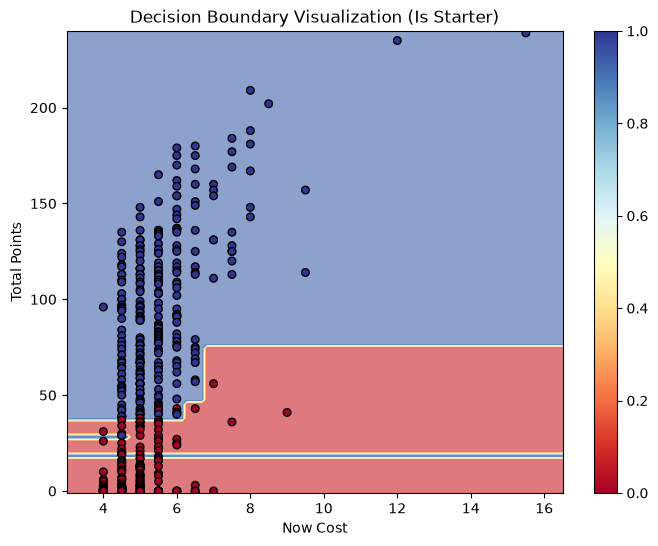

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 1. โหลดข้อมูล
df = pd.read_csv("fpl.csv")

# 2. สร้าง Target (1 = เล่น >= 900 นาที, 0 = สำรอง)
df["is_starter"] = (df["minutes"] >= 900).astype(int)

# 3. เลือก 2 Features หลัก เพื่อทำกราฟ 2 มิติ
feature_cols = ["now_cost", "total_points"]
X = df[feature_cols]
y = df["is_starter"]

# 4. แบ่งข้อมูล Train/Test และสร้าง โมเดล
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

# 5. วาดกราฟ Decision Boundary
fig, ax = plt.subplots(figsize=(8, 6))

# พลอตขอบเขตการจำแนกประเภท (Decision Boundary)
DecisionBoundaryDisplay.from_estimator(
    model,
    X,
    cmap=plt.cm.RdYlBu,
    alpha=0.6,
    ax=ax,
    xlabel="Now Cost",
    ylabel="Total Points",
    response_method="predict",
)

# พลอตจุดข้อมูลลงบนกราฟ
scatter = ax.scatter(
    X.iloc[:, 0],
    X.iloc[:, 1],
    c=y,
    cmap=plt.cm.RdYlBu,
    edgecolors="k",
    s=30,
)

plt.title("Decision Boundary Visualization (Is Starter)")
plt.colorbar(scatter)
plt.show()

*Logistic Regression*  

In [8]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. โหลดข้อมูล
df = pd.read_csv("fpl.csv")

# 2. สร้าง Target (1 = ลงเล่น >= 900 นาที, 0 = สำรอง)
df["is_starter"] = (df["minutes"] >= 900).astype(int)

# 3. เลือก Features (X) และ Target (y)
feature_cols = [
    "now_cost",
    "total_points",
    "goals_scored",
    "assists",
    "clean_sheets",
    "ict_index",
    "selected_by_percent",
]

X = df[feature_cols]
y = df["is_starter"]

# 4. แบ่งข้อมูล Train / Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Scaling ข้อมูล (Logistic Regression ได้ผลดีขึ้นเมื่อปรับ Scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. สร้างและ Train โมเดล Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# 7. ทำนายผลและประเมินประสิทธิภาพ
y_pred = model.predict(X_test_scaled)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 96.49%

Confusion Matrix:
[[57  3]
 [ 1 53]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97        60
           1       0.95      0.98      0.96        54

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.96       114



*Gender Prediction*

In [9]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. สร้าง/เตรียม ข้อมูลสำหรับทำนายเพศ (Gender Prediction)
# ใช้ Feature เช่น ความสูง (Height), น้ำหนัก (Weight), และ ขนาดเท้า (Foot Size)
np.random.seed(42)
n_samples = 500

# จำลองสถิติชาย/หญิง
height_m = np.random.normal(178, 7, n_samples // 2)
weight_m = np.random.normal(78, 10, n_samples // 2)
gender_m = np.ones(n_samples // 2)  # 1 = Male

height_f = np.random.normal(164, 6, n_samples // 2)
weight_f = np.random.normal(62, 8, n_samples // 2)
gender_f = np.zeros(n_samples // 2)  # 0 = Female

# รวมเป็น DataFrame
df_gender = pd.DataFrame(
    {
        "height": np.concatenate([height_m, height_f]),
        "weight": np.concatenate([weight_m, weight_f]),
        "gender": np.concatenate([gender_m, gender_f]),
    }
).sample(frac=1, random_state=42)  # สลับแถวข้อมูล

# 2. เลือก Features (X) และ Target (y)
X = df_gender[["height", "weight"]]
y = df_gender["gender"]

# 3. แบ่งข้อมูล Train / Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. สร้างและ Train โมเดล Logistic Regression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# 6. ทำนายผลและประเมินประสิทธิภาพ
y_pred = model.predict(X_test_scaled)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Female", "Male"]))

Accuracy Score: 92.00%

Confusion Matrix:
[[46  4]
 [ 4 46]]

Classification Report:
              precision    recall  f1-score   support

      Female       0.92      0.92      0.92        50
        Male       0.92      0.92      0.92        50

    accuracy                           0.92       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.92      0.92      0.92       100



*Confusion Matrix*  

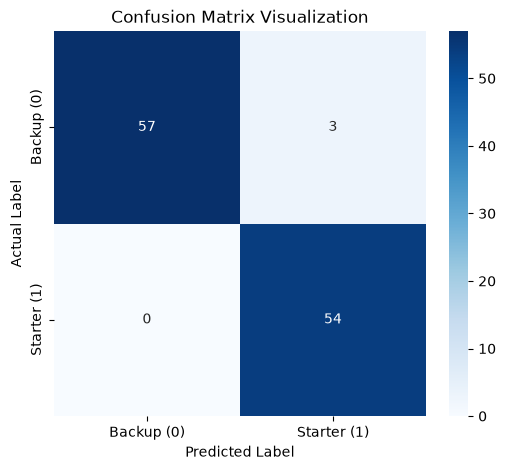

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. โหลดข้อมูล
df = pd.read_csv("fpl.csv")

# 2. สร้าง Target (1 = ตัวจริง/เล่น >= 900 นาที, 0 = สำรอง)
df["is_starter"] = (df["minutes"] >= 900).astype(int)

# 3. เลือก Features (X) และ Target (y)
feature_cols = [
    "now_cost",
    "total_points",
    "goals_scored",
    "assists",
    "ict_index",
]
X = df[feature_cols]
y = df["is_starter"]

# 4. แบ่งข้อมูล Train / Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Scaling และ Train โมเดล
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# 6. ทำนายผลและคำนวณ Confusion Matrix
y_pred = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

# 7. วาดกราฟ Heatmap ของ Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Backup (0)", "Starter (1)"],
    yticklabels=["Backup (0)", "Starter (1)"],
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Visualization")
plt.show()

**LAB 3: Model Comparison**

*Simple vs Multiple Linear Regression*  

In [11]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. โหลดข้อมูล
df = pd.read_csv("fpl.csv")
y = df["total_points"]

# ---------------------------------------------------------
# 1. Simple Linear Regression (ใช้ 1 Feature: minutes)
# ---------------------------------------------------------
X_simple = df[["minutes"]]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)
y_pred_s = model_simple.predict(X_test_s)

r2_s = r2_score(y_test_s, y_pred_s)
rmse_s = np.sqrt(mean_squared_error(y_test_s, y_pred_s))

# ---------------------------------------------------------
# 2. Multiple Linear Regression (ใช้หลาย Features)
# ---------------------------------------------------------
feature_cols = [
    "minutes",
    "goals_scored",
    "assists",
    "clean_sheets",
    "ict_index",
    "now_cost",
]
X_multi = df[feature_cols]
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)
y_pred_m = model_multi.predict(X_test_m)

r2_m = r2_score(y_test_m, y_pred_m)
rmse_m = np.sqrt(mean_squared_error(y_test_m, y_pred_m))

# ---------------------------------------------------------
# 3. แสดงตารางเปรียบเทียบผลลัพธ์
# ---------------------------------------------------------
comparison_df = pd.DataFrame(
    {
        "Model": ["Simple Linear Regression", "Multiple Linear Regression"],
        "Features Used": [
            "1 (minutes)",
            f"{len(feature_cols)} (minutes, goals, assists, etc.)",
        ],
        "R2 Score": [round(r2_s, 4), round(r2_m, 4)],
        "RMSE": [round(rmse_s, 2), round(rmse_m, 2)],
    }
)

print("=== Simple vs Multiple Linear Regression Comparison ===")
print(comparison_df.to_string(index=False))

=== Simple vs Multiple Linear Regression Comparison ===
                     Model                     Features Used  R2 Score  RMSE
  Simple Linear Regression                       1 (minutes)    0.9040 16.71
Multiple Linear Regression 6 (minutes, goals, assists, etc.)    0.9721  9.01


*Training vs Testing Performance*  

In [12]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

# 1. โหลดข้อมูล
df = pd.read_csv("fpl.csv")

# 2. เลือก Features และ Target (total_points)
feature_cols = [
    "now_cost",
    "minutes",
    "goals_scored",
    "assists",
    "clean_sheets",
    "ict_index",
]
X = df[feature_cols]
y = df["total_points"]

# 3. แบ่งข้อมูล Train / Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. โมเดลที่ต้องการทดสอบ
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree (Unconstrained)": DecisionTreeRegressor(random_state=42),
    "Decision Tree (Max Depth=5)": DecisionTreeRegressor(
        max_depth=5, random_state=42
    ),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100, random_state=42
    ),
}

# 5. วัดผล Performance ทั้ง Train และ Test
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    # ทำนายผลทั้ง Train และ Test set
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # คำนวณ R2 Score
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # คำนวณ RMSE
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    results.append(
        {
            "Model": name,
            "Train R2": round(train_r2, 4),
            "Test R2": round(test_r2, 4),
            "Train RMSE": round(train_rmse, 2),
            "Test RMSE": round(test_rmse, 2),
            "Gap (Train-Test R2)": round(train_r2 - test_r2, 4),
        }
    )

# 6. แสดงผลเปรียบเทียบ
results_df = pd.DataFrame(results)
print("=== Training vs Testing Performance Comparison ===")
print(results_df.to_string(index=False))

=== Training vs Testing Performance Comparison ===
                        Model  Train R2  Test R2  Train RMSE  Test RMSE  Gap (Train-Test R2)
            Linear Regression    0.9786   0.9721        7.84       9.01               0.0065
Decision Tree (Unconstrained)    1.0000   0.9279        0.00      14.47               0.0721
  Decision Tree (Max Depth=5)    0.9777   0.9439        7.99      12.77               0.0338
      Random Forest Regressor    0.9947   0.9676        3.89       9.70               0.0271


*Regression vs Classification*  

In [13]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

# 1. โหลดข้อมูล
df = pd.read_csv("fpl.csv")

# เลือก Features หลักที่ใช้ร่วมกัน
feature_cols = [
    "now_cost",
    "minutes",
    "goals_scored",
    "assists",
    "clean_sheets",
    "ict_index",
]

# =========================================================
# 1. REGRESSION: พยากรณ์ค่าต่อเนื่อง (Continuous Value)
# Target: total_points (คะแนนรวม - เป็นตัวเลขต่อเนื่อง)
# =========================================================
X_reg = df[feature_cols]
y_reg = df["total_points"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train_r, y_train_r)
y_pred_r = reg_model.predict(X_test_r)

print("=" * 50)
print("📌 1. REGRESSION RESULTS (Predicting Total Points)")
print("=" * 50)
print(f"R2 Score : {r2_score(y_test_r, y_pred_r):.4f}")
print(f"MAE      : {mean_absolute_error(y_test_r, y_pred_r):.2f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test_r, y_pred_r)):.2f}\n")

# =========================================================
# 2. CLASSIFICATION: พยากรณ์กลุ่ม/ประเภท (Discrete Class)
# Target: is_starter (1 = เล่น >= 900 นาที, 0 = สำรอง)
# =========================================================
df["is_starter"] = (df["minutes"] >= 900).astype(int)

X_cls = df[feature_cols]
y_cls = df["is_starter"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

cls_model = RandomForestClassifier(n_estimators=100, random_state=42)
cls_model.fit(X_train_c, y_train_c)
y_pred_c = cls_model.predict(X_test_c)

print("=" * 50)
print("📌 2. CLASSIFICATION RESULTS (Predicting Is Starter)")
print("=" * 50)
print(f"Accuracy Score: {accuracy_score(y_test_c, y_pred_c) * 100:.2f}%\n")
print("Classification Report:")
print(
    classification_report(y_test_c, y_pred_c, target_names=["Backup", "Starter"])
)

📌 1. REGRESSION RESULTS (Predicting Total Points)
R2 Score : 0.9676
MAE      : 5.50
RMSE     : 9.70

📌 2. CLASSIFICATION RESULTS (Predicting Is Starter)
Accuracy Score: 100.00%

Classification Report:
              precision    recall  f1-score   support

      Backup       1.00      1.00      1.00        60
     Starter       1.00      1.00      1.00        54

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114



*Model Performance Metrics*

In [14]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

# 1. โหลดข้อมูล
df = pd.read_csv("fpl.csv")

# เลือก Features หลัก
feature_cols = [
    "now_cost",
    "minutes",
    "goals_scored",
    "assists",
    "clean_sheets",
    "ict_index",
]

# =========================================================
# 1. REGRESSION PERFORMANCE METRICS
# =========================================================
X_reg = df[feature_cols]
y_reg = df["total_points"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train_r, y_train_r)
y_pred_r = reg_model.predict(X_test_r)

# คำนวณ Metrics สำหรับ Regression
mae = mean_absolute_error(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred_r)

print("=" * 50)
print("📊 REGRESSION PERFORMANCE METRICS")
print("=" * 50)
print(f"R-squared (R²)          : {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"Root Mean Sq. Err (RMSE) : {rmse:.4f}\n")

# =========================================================
# 2. CLASSIFICATION PERFORMANCE METRICS
# =========================================================
df["is_starter"] = (df["minutes"] >= 900).astype(int)

X_cls = df[feature_cols]
y_cls = df["is_starter"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

cls_model = RandomForestClassifier(n_estimators=100, random_state=42)
cls_model.fit(X_train_c, y_train_c)
y_pred_c = cls_model.predict(X_test_c)

# คำนวณ Metrics สำหรับ Classification
acc = accuracy_score(y_test_c, y_pred_c)
prec = precision_score(y_test_c, y_pred_c)
rec = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)

print("=" * 50)
print("📊 CLASSIFICATION PERFORMANCE METRICS")
print("=" * 50)
print(f"Accuracy  : {acc * 100:.2f}%")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")

📊 REGRESSION PERFORMANCE METRICS
R-squared (R²)          : 0.9676
Mean Absolute Error (MAE): 5.4997
Mean Squared Error (MSE) : 94.1515
Root Mean Sq. Err (RMSE) : 9.7032

📊 CLASSIFICATION PERFORMANCE METRICS
Accuracy  : 100.00%
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000
